In [18]:
import pandas as pd
import numpy as np
from fitter import Fitter
import matplotlib.pyplot as plt
import yfinance as yf

## S&P 500

In [57]:
# SP500
sp500 = yf.download("^GSPC", interval="1d", start="2025-03-24", end="2026-03-24")
sp500.to_csv("sp500_data.csv")

# DOW JONES
dow = yf.download("^DJI", interval="1d", start="2025-03-24", end="2026-03-24")
dow.to_csv("dowjones_data.csv")

# NASDAQ 100
nasdaq100 = yf.download("^NDX", interval="1d", start="2025-03-24", end="2026-03-24")
nasdaq100.to_csv("nasdaq100_data.csv")

# S&P/BMV IPC (México)
ipc = yf.download("^MXX", interval="1d", start="2025-03-24", end="2026-03-24")
ipc.to_csv("ipc_mexico_data.csv")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [64]:
def load_data(file):
    df = pd.read_csv(file, header=2)
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

    print(df.columns)

    df["Date"] = pd.to_datetime(df["Date"])
    df["Close"] = pd.to_numeric(df["Close"])

    df = df.sort_values("Date")
    print(df.columns)

    return df

### Find out whether it closed on a high or on a low with regards to the closing of the last week 

In [65]:
def process_data(df):
    df["prev_close"] = df["Close"].shift(1)
    df["bullish"] = (df["Close"] > df["prev_close"]).astype(int)

    df = df.dropna(subset=["prev_close"])

    df["week"] = df["Date"].dt.to_period("W")
    weekly_bullish_counts = df.groupby("week")["bullish"].sum()
    
    print(weekly_bullish_counts)
    return weekly_bullish_counts

### Histogram 

In [66]:
def plot_histogram(weekly_bullish_counts, title):
    plt.figure(figsize=(8,5))

    plt.hist(weekly_bullish_counts.values, bins=range(0,7), edgecolor='black')

    plt.title(title)
    plt.xlabel("Número de días bullish en la semana")
    plt.ylabel("Frecuencia (número de semanas)")

    plt.xticks(range(0,7))
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

### Fitting distribution 

In [70]:
def fit_distribution(weekly_bullish_counts, title):
    f = Fitter(weekly_bullish_counts.values)
    f.fit()

    best = f.get_best(method='sumsquare_error')
    best_name = list(best.keys())[0]

    print("\nBest distribution:", best_name)
    print("Parameters:", best[best_name])

    # Plot summary with title
    plt.figure(figsize=(8,5))
    f.summary()

    plt.title(f"{title} \nBest fit: {best_name}")
    plt.xlabel("Number of Bullish Days per Week")
    plt.ylabel("Density")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return f

In [68]:
def compare_indices(dict_of_series):
    df = pd.DataFrame(dict_of_series)
    corr = df.corr()

    print("\nCorrelation Matrix:")
    print(corr)

    return corr

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')
week
2025-03-24/2025-03-30    1
2025-03-31/2025-04-06    3
2025-04-07/2025-04-13    2
2025-04-14/2025-04-20    2
2025-04-21/2025-04-27    4
2025-04-28/2025-05-04    5
2025-05-05/2025-05-11    2
2025-05-12/2025-05-18    5
2025-05-19/2025-05-25    1
2025-05-26/2025-06-01    2
2025-06-02/2025-06-08    4
2025-06-09/2025-06-15    3
2025-06-16/2025-06-22    1
2025-06-23/2025-06-29    4
2025-06-30/2025-07-06    3
2025-07-07/2025-07-13 

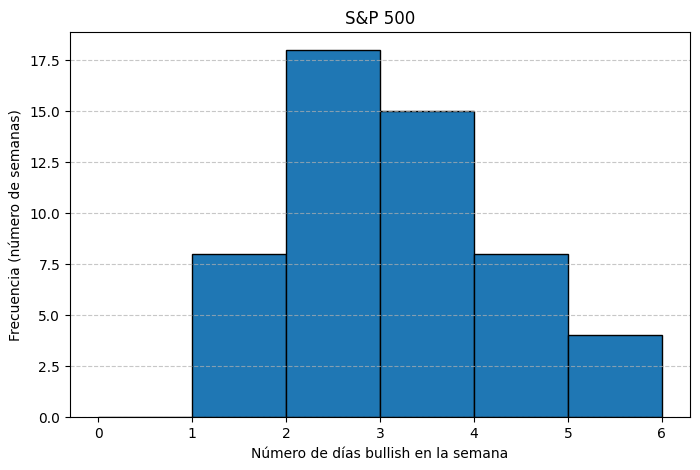

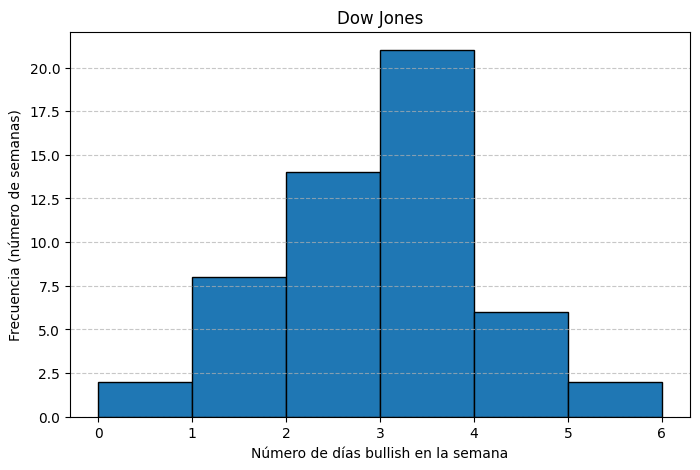

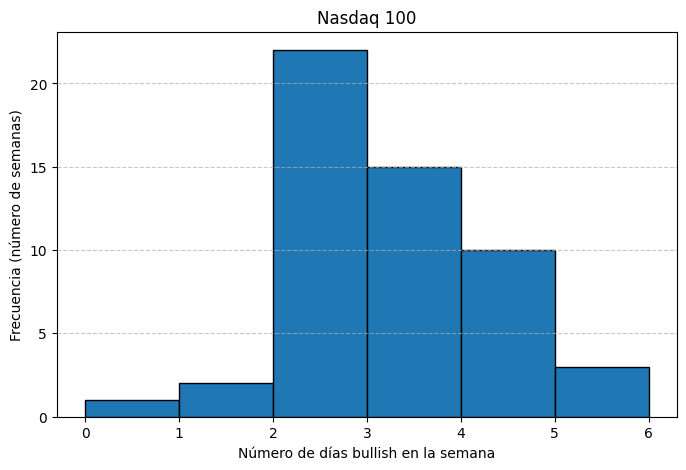

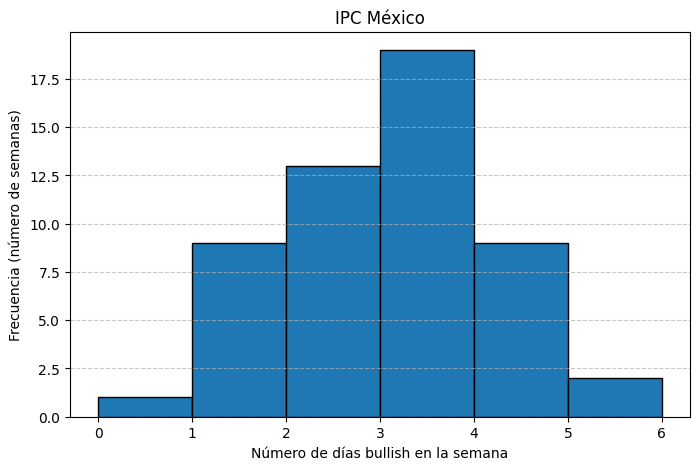

2026-03-29 22:54:18.454 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED _fit: TypeError (timeout=30s or fitting failed)
2026-03-29 22:54:18.460 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted anglit: error=148.148970, AIC=163.71, KS=0.2323
2026-03-29 22:54:18.465 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted alpha: error=147.959393, AIC=167.49, KS=0.1906
2026-03-29 22:54:18.466 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted arcsine: error=147.197606, AIC=50.42, KS=0.2524
2026-03-29 22:54:18.468 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted argus: error=148.792348, AIC=172.19, KS=0.2980
2026-03-29 22:54:18.472 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted bradford: error=147.506930, AIC=149.02, KS=0.1968
2026-03-29 22:54:18.475 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=148.729876, AIC=190.55, KS=0.2053
2026-03-29 22:54:18.477 | INFO     | fit


Correlation Matrix:
              SP500       DOW  NASDAQ100       IPC
SP500      1.000000  0.753833   0.791499  0.354753
DOW        0.753833  1.000000   0.628870  0.344128
NASDAQ100  0.791499  0.628870   1.000000  0.529080
IPC        0.354753  0.344128   0.529080  1.000000


2026-03-29 22:56:19.795 | WARNING  | fitter.fitter:_fit_single_distribution:422 - SKIPPED studentized_range: TimeoutError (timeout=30s or fitting failed)
2026-03-29 22:56:19.960 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted t: error=94.409587, AIC=168.58, KS=0.2041


,SP500,DOW,NASDAQ100,IPC
SP500,1.000000,0.753833,0.791499,0.354753
DOW,0.753833,1.000000,0.628870,0.344128
NASDAQ100,0.791499,0.628870,1.000000,0.529080
IPC,0.354753,0.344128,0.529080,1.000000


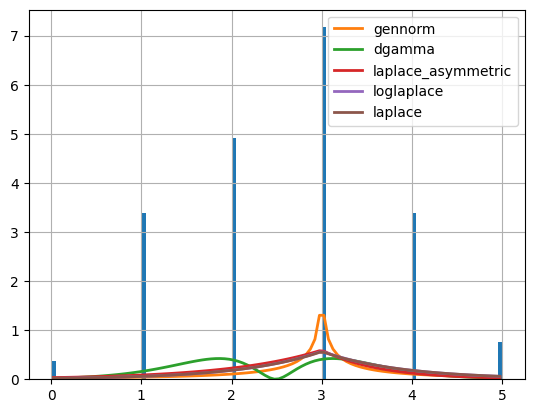

In [69]:
# Load each dataset
sp500 = load_data("sp500_data.csv")
dow = load_data("dowjones_data.csv")
nasdaq = load_data("nasdaq100_data.csv")
ipc = load_data("ipc_mexico_data.csv")

# Process each
sp500_w = process_data(sp500)
dow_w = process_data(dow)
nasdaq_w = process_data(nasdaq)
ipc_w = process_data(ipc)

# Plot
plot_histogram(sp500_w, "S&P 500")
plot_histogram(dow_w, "Dow Jones")
plot_histogram(nasdaq_w, "Nasdaq 100")
plot_histogram(ipc_w, "IPC México")

# Fit distributions
fit_distribution(sp500_w, "S&P 500")
fit_distribution(dow_w, "Dow Jones")
fit_distribution(nasdaq_w, "Nasdaq 100")
fit_distribution(ipc_w, "IPC México")

# Compare correlations
compare_indices({
    "SP500": sp500_w,
    "DOW": dow_w,
    "NASDAQ100": nasdaq_w,
    "IPC": ipc_w
})